In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_19608\3576454766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


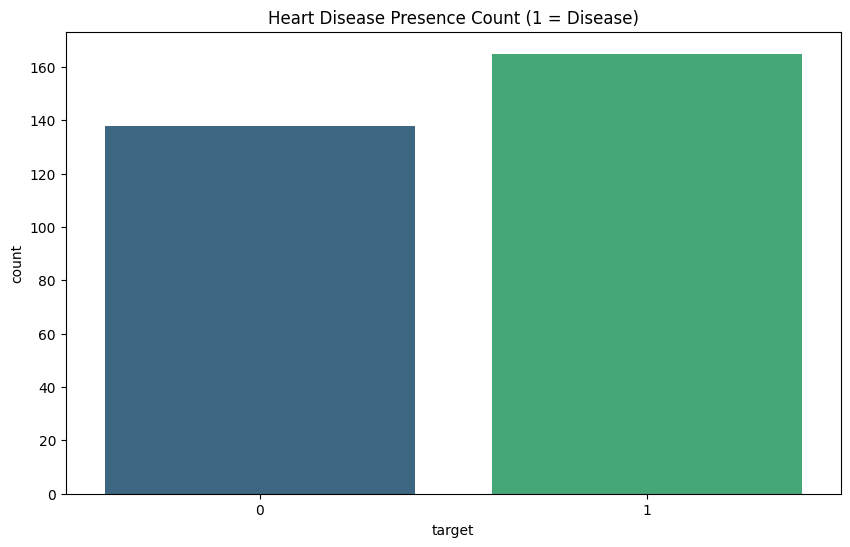

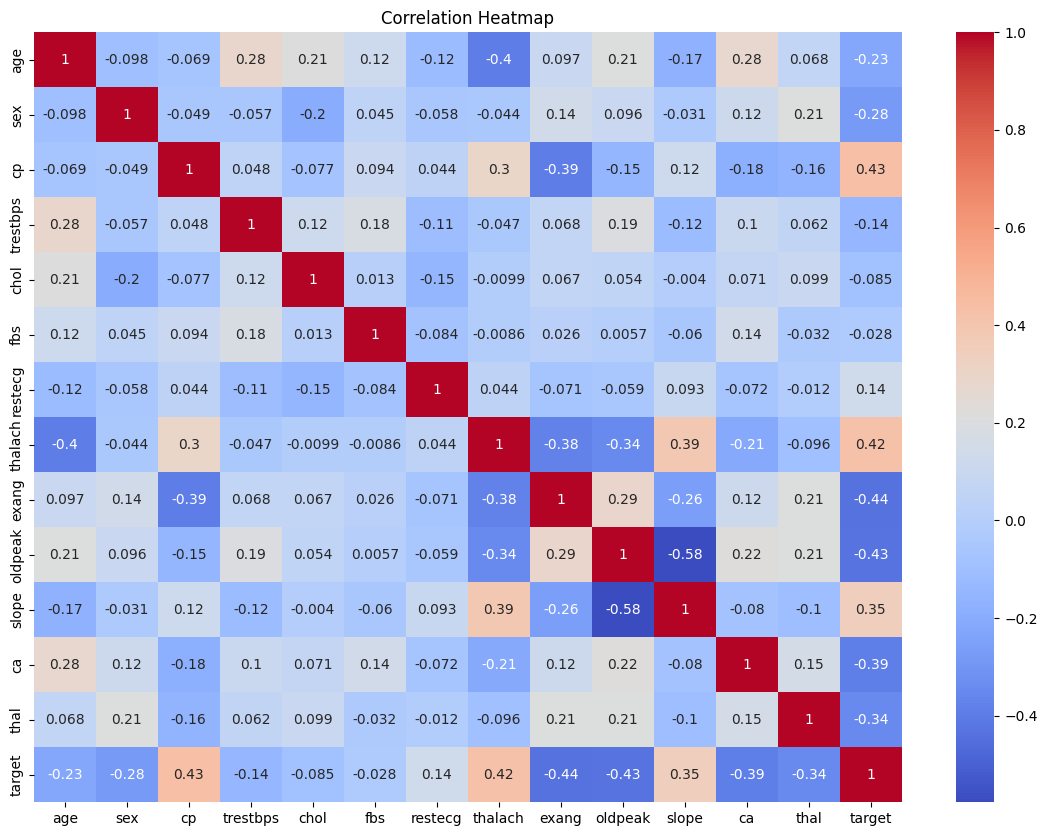

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(x='target', data=df, palette='viridis')
plt.title("Heart Disease Presence Count (1 = Disease)")
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [5]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy (Logistic Regression): 0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.8360655737704918
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [9]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy (SVM): 0.8688524590163934
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



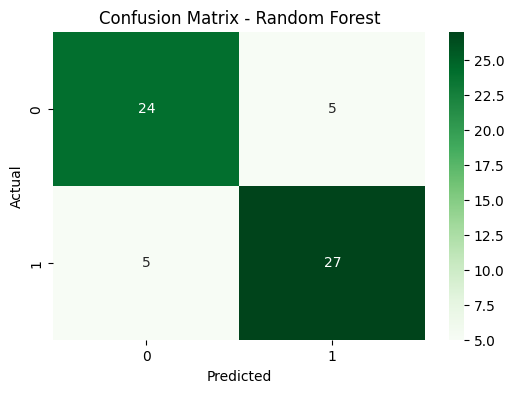

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_scaled, y)

joblib.dump(model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model trained and saved")


Model trained and saved


In [1]:
import streamlit as st
import numpy as np
import joblib
import random

model = joblib.load("heart_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("❤️ AI Heart Disease Detection App")
st.subheader("Early Health Risk Screening System")

st.markdown("⚠️ *Sensor values are simulated for educational purposes*")

# --- User Inputs ---
age = st.slider("Age", 18, 100, 45)
sex = st.selectbox("Gender", [0, 1])  # 0=female, 1=male
cp = st.selectbox("Chest Pain Type (0-3)", [0,1,2,3])
bp = st.slider("Resting Blood Pressure", 80, 200, 120)
chol = st.slider("Cholesterol Level", 100, 400, 200)
fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0,1])
thalach = st.slider("Max Heart Rate Achieved", 70, 220, 150)
exang = st.selectbox("Exercise Induced Angina", [0,1])
oldpeak = st.slider("ST Depression", 0.0, 6.0, 1.0)
ca = st.selectbox("Major Blood Vessels (0-4)", [0,1,2,3,4])
thal = st.selectbox("Thalassemia Type", [0,1,2,3])

# --- Sensor Simulation ---
pulse_rate = random.randint(60, 110)
heartbeat_rate = random.randint(60, 120)

st.subheader("📟 Sensor Readings")
st.metric("Pulse Rate (bpm)", pulse_rate)
st.metric("Heart Beat Rate (bpm)", heartbeat_rate)

# --- Prediction ---
if st.button("Check Heart Health"):
    data = np.array([[age, sex, cp, bp, chol, fbs, 0,
                      thalach, exang, oldpeak, 1, ca, thal]])

    data = scaler.transform(data)
    result = model.predict(data)[0]

    st.subheader("🧠 AI Diagnosis Result")

    if result == 0:
        st.success("✅ No Heart Disease Detected")
    elif result == 1:
        st.warning("⚠️ Possible Angina Detected")
    elif result == 2:
        st.warning("⚠️ Risk of Myocardial Infarction")
    elif result == 3:
        st.warning("⚠️ Structural / Congenital Heart Issue")
    else:
        st.error("🚨 Severe Heart Disease Risk")

    st.info("📌 Please consult a certified cardiologist for medical advice.")


2026-01-14 20:59:35.954 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.055 
  command:

    streamlit run C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-14 20:59:37.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-14 20:59:37.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load dataset
df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save files
joblib.dump(model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")


Model and Scaler saved successfully!
